In [1]:
import os 
os.chdir("..")
print(os.getcwd())
import gc
import torch

d:\pythonProject\IC Lab\Gait_analysis\pyskl



各類別樣本數量：
Cluster 0: 59 人
Cluster 1: 12 人


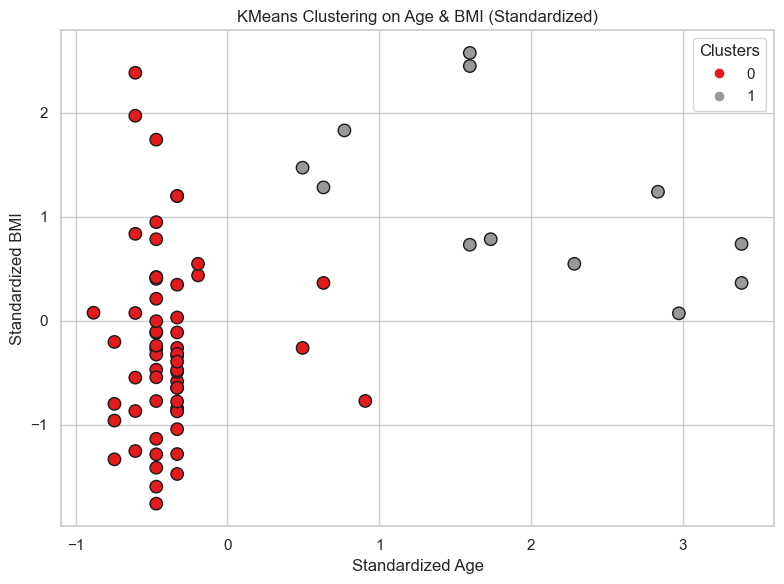

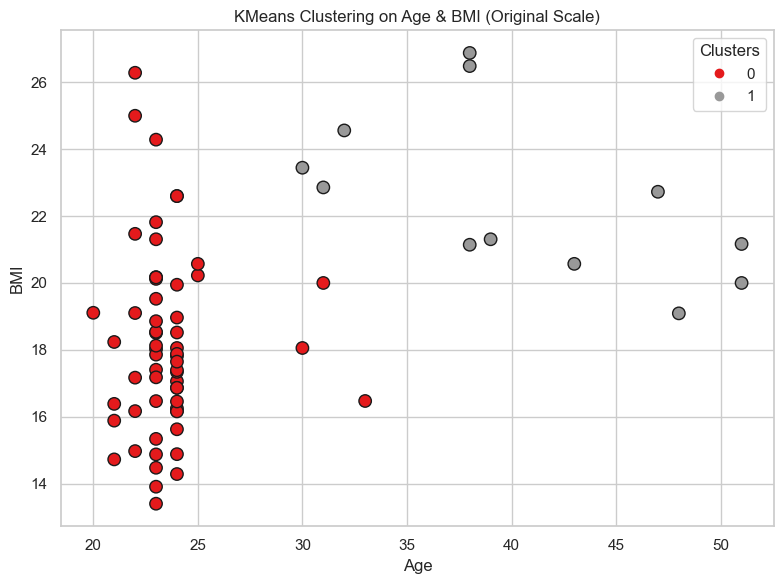

C:\Users\User\AppData\Local\Temp\ipykernel_58168\1490280555.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Cluster", y="年齡(歲)", ax=axes[0], palette="Set2")
C:\Users\User\AppData\Local\Temp\ipykernel_58168\1490280555.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Cluster", y="BMI", ax=axes[1], palette="Set2")
C:\Users\User\AppData\Local\Temp\ipykernel_58168\1490280555.py:72: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_58168\1490280555.py:72: UserWarning: Glyph 40801 (\N{CJK UNIFIED IDEOGRAPH-9F61}) missing from font(s) Arial.
  plt.tig

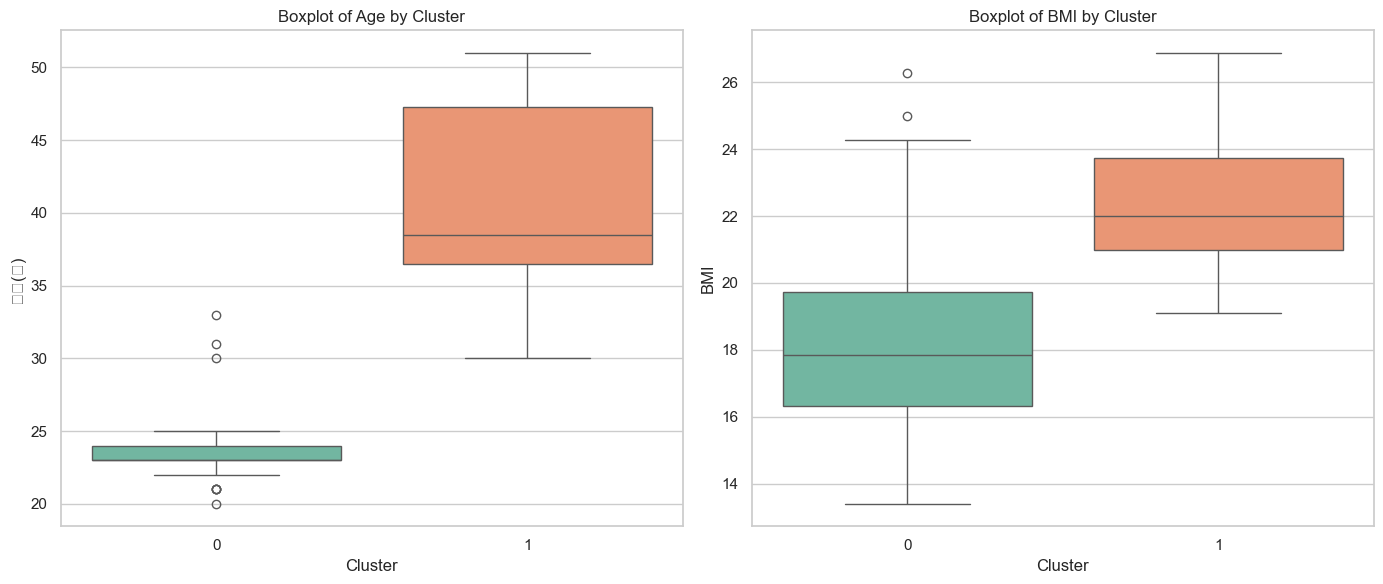

已儲存至：分群結果_酒精步態資料_age&BMI.xlsx


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 讀取資料
file_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})

# 僅取用「年齡」與「BMI」，並移除缺失值
features = df[['年齡(歲)', 'BMI']].dropna()

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# KMeans 分群（2 群）
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 建立分群結果 DataFrame
df_cleaned = df.loc[features.index].copy()
df_cleaned['Cluster'] = clusters
df_cleaned['Cluster'] = df_cleaned['Cluster'].astype(str)

# 顯示各群的樣本數
cluster_counts = df_cleaned['Cluster'].value_counts().sort_index()
print("\n各類別樣本數量：")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} 人")

# ✅ 散佈圖（標準化後的年齡 vs. BMI）
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=clusters, cmap='Set1', edgecolors='k', s=80
)
plt.title('KMeans Clustering on Age & BMI (Standardized)')
plt.xlabel('Standardized Age')
plt.ylabel('Standardized BMI')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# ✅ 散佈圖（原始年齡 vs. BMI 單位）
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    features['年齡(歲)'], features['BMI'],
    c=clusters, cmap='Set1', edgecolors='k', s=80
)
plt.title('KMeans Clustering on Age & BMI (Original Scale)')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# ✅ Boxplot 比較各群分布（使用 Seaborn）
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_cleaned, x="Cluster", y="年齡(歲)", ax=axes[0], palette="Set2")
axes[0].set_title("Boxplot of Age by Cluster")

sns.boxplot(data=df_cleaned, x="Cluster", y="BMI", ax=axes[1], palette="Set2")
axes[1].set_title("Boxplot of BMI by Cluster")

plt.tight_layout()
plt.show()

# ✅ 儲存分群結果
save_path = "分群結果_酒精步態資料_age&BMI.xlsx"
df_cleaned.to_excel(save_path, index=False)
print(f"已儲存至：{save_path}")



各類別樣本數量：
Cluster 0: 41 人
Cluster 1: 30 人


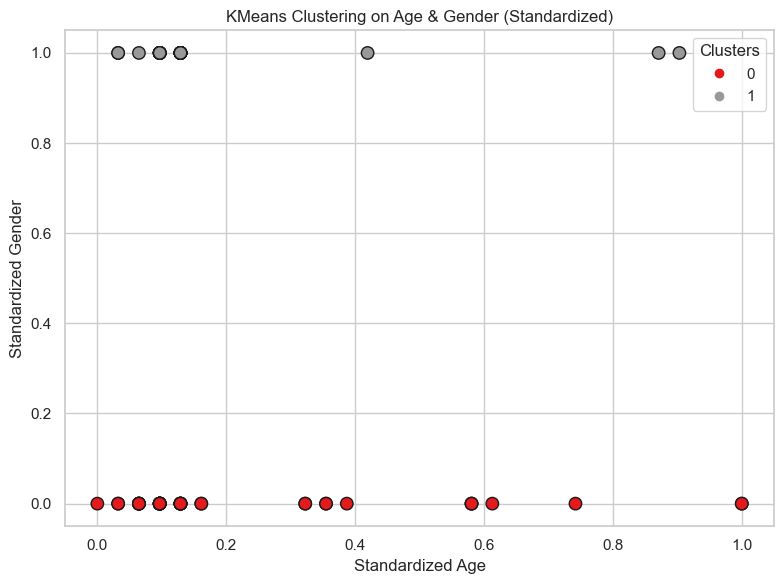

C:\Users\User\AppData\Local\Temp\ipykernel_58168\3976037190.py:58: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_58168\3976037190.py:58: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) Arial.
  plt.tight_layout()
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


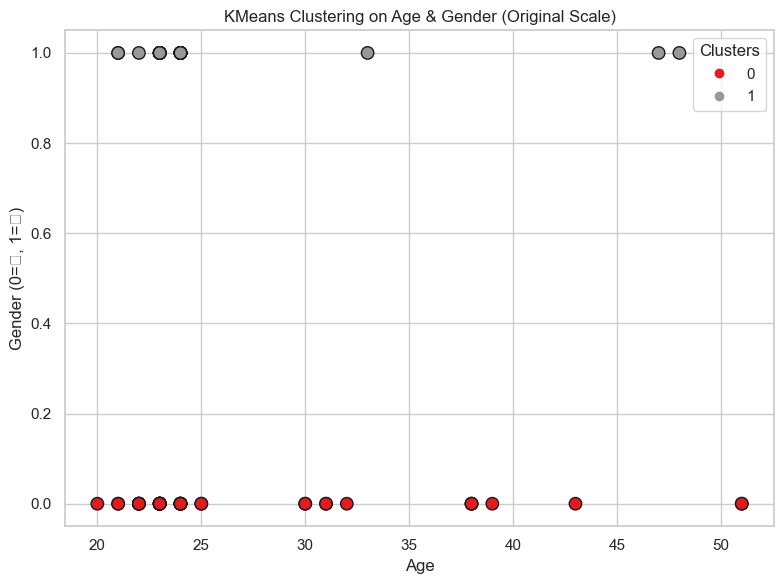

C:\Users\User\AppData\Local\Temp\ipykernel_58168\3976037190.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Cluster", y="年齡(歲)", ax=axes[0], palette="Set2")
C:\Users\User\AppData\Local\Temp\ipykernel_58168\3976037190.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="Cluster", y="性別", ax=axes[1], palette="Set2")
C:\Users\User\AppData\Local\Temp\ipykernel_58168\3976037190.py:71: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_58168\3976037190.py:71: UserWarning: Glyph 40801 (\N{CJK UNIFIED IDEOGRAPH-9F61}) missing from font(s) Arial.
  plt.tigh

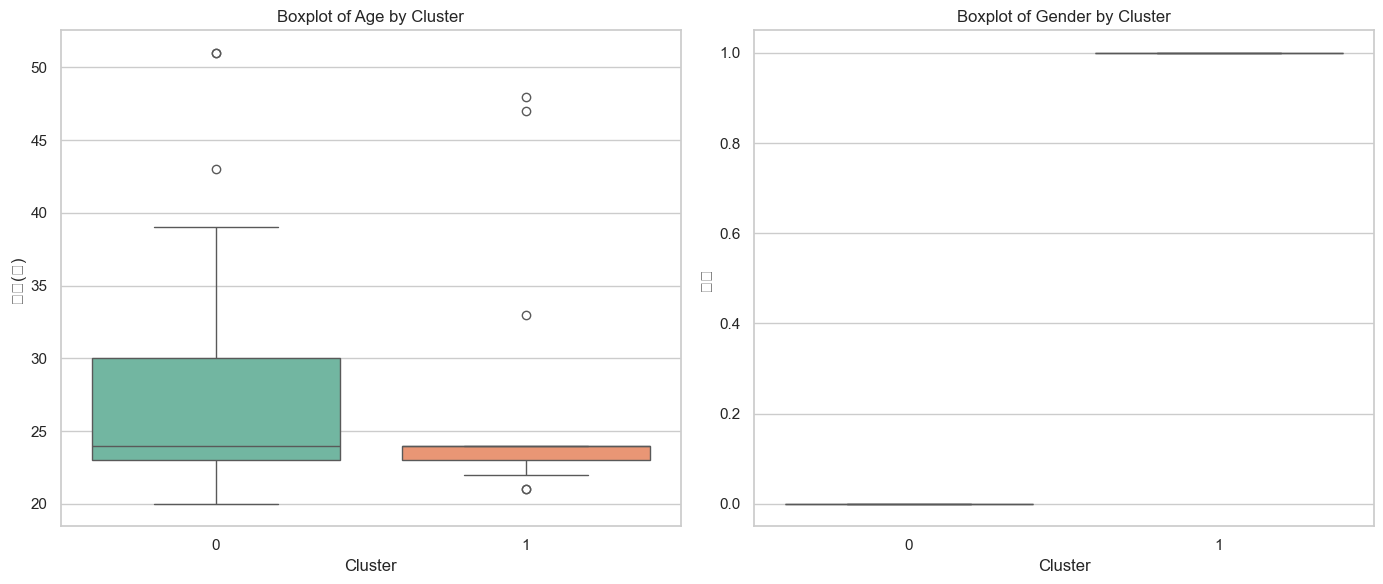

已儲存至：分群結果_酒精步態資料_age&gender.xlsx


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 讀取資料
file_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})

# 改為取用「年齡」與「性別」
features = df[['年齡(歲)', '性別', 'BMI']].dropna()

# 標準化
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features)

# KMeans 分群（2 群）
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 建立分群結果 DataFrame
df_cleaned = df.loc[features.index].copy()
df_cleaned['Cluster'] = clusters.astype(str)

# 顯示各群的樣本數
cluster_counts = df_cleaned['Cluster'].value_counts().sort_index()
print("\n各類別樣本數量：")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} 人")

# 散佈圖（標準化後的年齡 vs. 性別）
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=clusters, cmap='Set1', edgecolors='k', s=80
)
plt.title('KMeans Clustering on Age & Gender (Standardized)')
plt.xlabel('Standardized Age')
plt.ylabel('Standardized Gender')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# 散佈圖（原始年齡 vs. 性別）
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    features['年齡(歲)'], features['性別'],
    c=clusters, cmap='Set1', edgecolors='k', s=80
)
plt.title('KMeans Clustering on Age & Gender (Original Scale)')
plt.xlabel('Age')
plt.ylabel('Gender (0=男, 1=女)')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# Boxplot 比較各群分布（使用 Seaborn）
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_cleaned, x="Cluster", y="年齡(歲)", ax=axes[0], palette="Set2")
axes[0].set_title("Boxplot of Age by Cluster")

sns.boxplot(data=df_cleaned, x="Cluster", y="性別", ax=axes[1], palette="Set2")
axes[1].set_title("Boxplot of Gender by Cluster")

plt.tight_layout()
plt.show()

# 儲存分群結果
save_path = "分群結果_酒精步態資料_age&gender.xlsx"
df_cleaned.to_excel(save_path, index=False)
print(f"已儲存至：{save_path}")


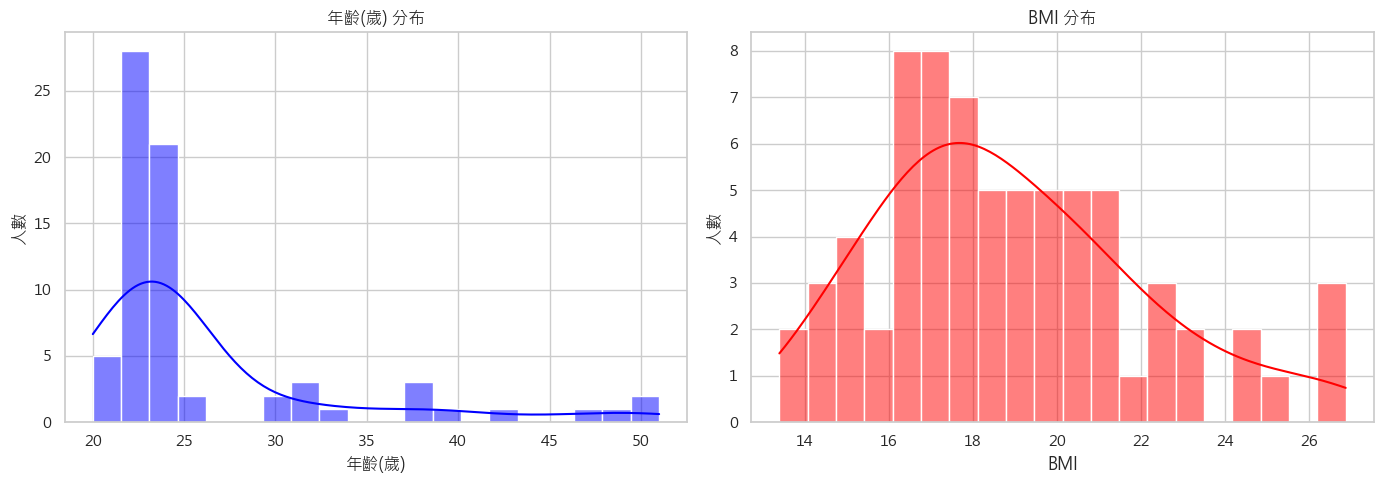

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
file_path = r"data/drunk71_small/info.xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})
features = df[['年齡(歲)', 'BMI']].dropna()

# 設定視覺風格
sns.set(style="whitegrid", font='Microsoft JhengHei')

# 繪製分布圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(features['年齡(歲)'], kde=True, bins=20, ax=axes[0], color="blue")
axes[0].set_title('年齡(歲) 分布')
axes[0].set_xlabel('年齡(歲)')
axes[0].set_ylabel('人數')

sns.histplot(features['BMI'], kde=True, bins=20, ax=axes[1], color="red")
axes[1].set_title('BMI 分布')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('人數')

plt.tight_layout()
plt.show()

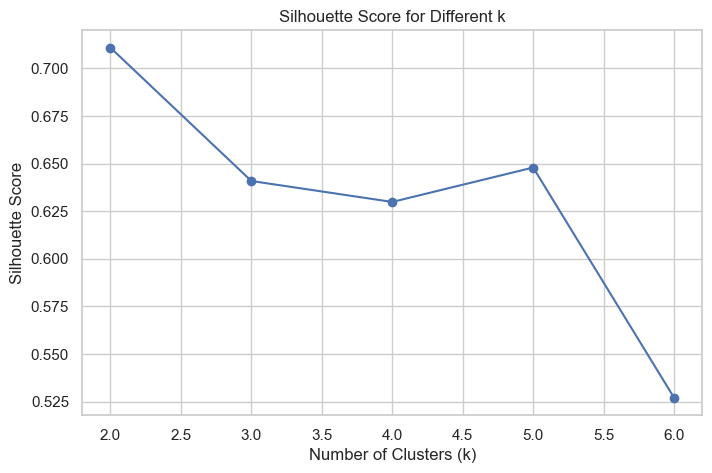

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)  # 你用 MinMaxScaler 或 StandardScaler 的結果
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# 繪圖
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


各類別樣本數量：
Cluster 0: 41 人
Cluster 1: 30 人


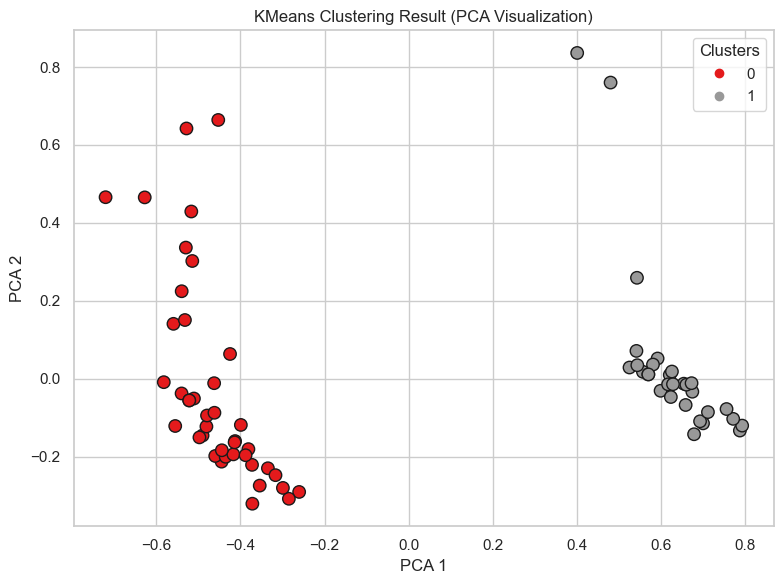

已儲存至：分群結果_酒精步態資料_age&bmi&height&sex.xlsx


C:\Users\User\AppData\Local\Temp\ipykernel_58168\1758503912.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_58168\1758503912.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Cluster 0', 'Cluster 1'])  # 視覺顯示對應順序
C:\Users\User\AppData\Local\Temp\ipykernel_58168\1758503912.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_58168\1758503912.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_

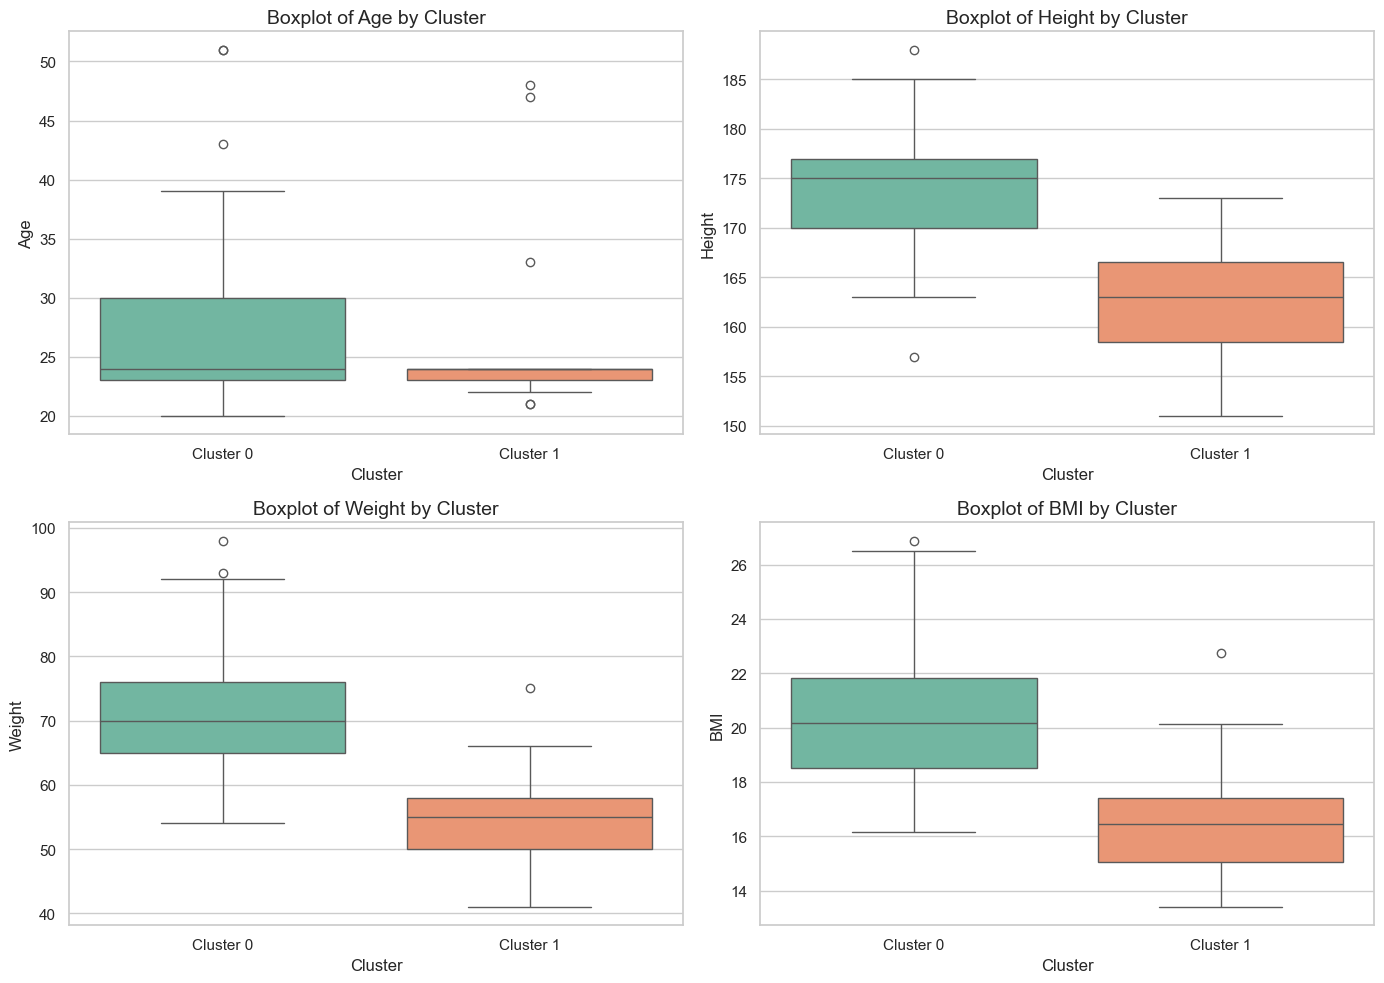

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 讀取 Excel 檔案
file_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})
# 選擇要用來分群的欄位並移除缺失值
# features = df[['年齡(歲)', 'BMI']].dropna()
features = df[['年齡(歲)', 'BMI', '性別', '身高(cm)']].dropna()
# 標準化
#scaler = StandardScaler()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features)

# KMeans 分為 2 群
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 記錄分群結果
df_cleaned = df.loc[features.index].copy()
df_cleaned['Cluster'] = clusters

# 選擇性標記每個類別為 True/False（例如 Cluster 0）
df_cleaned['Cluster_0'] = df_cleaned['Cluster'] == 0
df_cleaned['Cluster_1'] = df_cleaned['Cluster'] == 1

from sklearn.decomposition import PCA

# PCA 降到 2 維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 顯示各群的樣本數
cluster_counts = df_cleaned['Cluster'].value_counts().sort_index()
print("\n各類別樣本數量：")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} 人")

# 繪圖：顯示 KMeans 分群後的結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', edgecolors='k', s=80)
plt.title('KMeans Clustering Result (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="best")
plt.tight_layout()
plt.show()

# 儲存為新檔案
save_path = "分群結果_酒精步態資料_age&bmi&height&sex.xlsx"
df_cleaned.to_excel(save_path, index=False)
print(f"已儲存至：{save_path}")

# 設定 Seaborn 樣式
sns.set(style="whitegrid")

# 確保 Cluster 是字串，利於分組
df_cleaned["Cluster"] = df_cleaned["Cluster"].astype(str)

# 欲繪製的欄位與標題
variables = ["年齡(歲)", "身高(cm)", "體重(kg)", "BMI"]
titles = ["Age", "Height", "Weight", "BMI"]

# 建立子圖
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 繪圖
for i, (var, title) in enumerate(zip(variables, titles)):
    sns.boxplot(
        data=df_cleaned,
        x="Cluster",
        y=var,
        ax=axes[i],
        palette="Set2",
        order=["0", "1"]  # 這行控制順序：左邊是 1 → 右邊是 0
    )
    axes[i].set_title(f"Boxplot of {title} by Cluster", fontsize=14)
    axes[i].set_xlabel("Cluster", fontsize=12)
    axes[i].set_ylabel(title, fontsize=12)
    axes[i].set_xticklabels(['Cluster 0', 'Cluster 1'])  # 視覺顯示對應順序

plt.tight_layout()
plt.show()


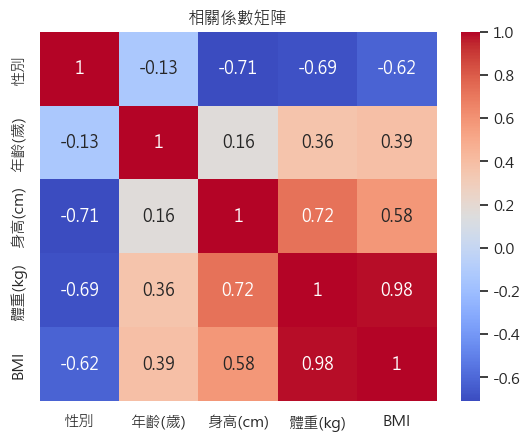

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

# 設定中文字型（適用於 Windows）
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # 或 'DFKai-SB'（標楷體）
plt.rcParams['axes.unicode_minus'] = False  # 避免負號顯示錯誤

# 假設你有 df 包含中文欄位
corr_matrix = df[['性別', "年齡(歲)", "身高(cm)", "體重(kg)", "BMI"]].corr()

# 繪製熱力圖
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("相關係數矩陣")  # 中文標題
plt.show()


In [63]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 假設 df 已經讀進來，且包含中文欄位
X = df[["年齡(歲)", "BMI"]].dropna()  # 移除 NA
X = add_constant(X)  # 加入常數項（intercept）

# 計算每個欄位的 VIF 值
vif_data = pd.DataFrame()
vif_data["變數"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

      變數        VIF
0  const  39.806721
1  年齡(歲)   1.176719
2    BMI   1.176719


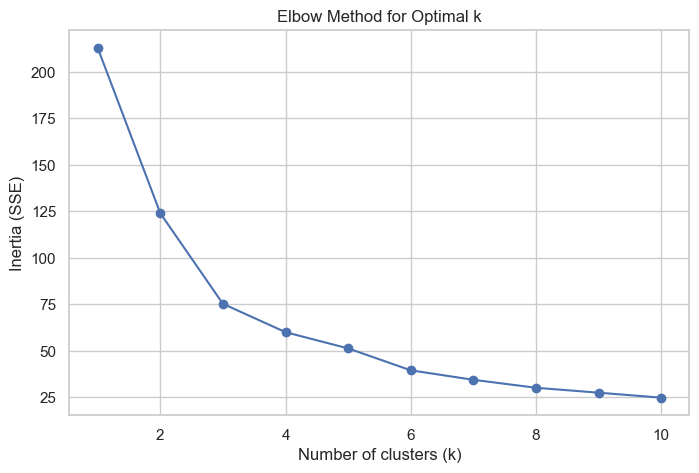

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# 讀資料與預處理
file_path = r"C:\Users\User\Downloads\酒精步態資料集受試者資訊 (回覆) (1).xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})
features = df[['年齡(歲)', 'BMI', '身高(cm)']].dropna()

# 標準化數據（很重要！）
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 計算 KMeans inertia (SSE) 來畫 elbow curve
inertias = []
k_range = range(1, 11)  # 試不同的群數 k=1~10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

# 畫圖
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


In [20]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 假設你已經有 scaled_features (標準化後的資料)

best_score = -1
best_k = 2

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"k={k} → silhouette score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\n✅ Best k = {best_k} with silhouette score = {best_score:.4f}")

k=2 → silhouette score = 0.3858
k=3 → silhouette score = 0.4101
k=4 → silhouette score = 0.3667
k=5 → silhouette score = 0.3764
k=6 → silhouette score = 0.3305
k=7 → silhouette score = 0.3280
k=8 → silhouette score = 0.3290
k=9 → silhouette score = 0.3196
k=10 → silhouette score = 0.3260

✅ Best k = 3 with silhouette score = 0.4101


# KNN

d:\pythonProject\IC Lab\venv\lib\site-packages\sklearn\cluster\_agglomerative.py:323: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


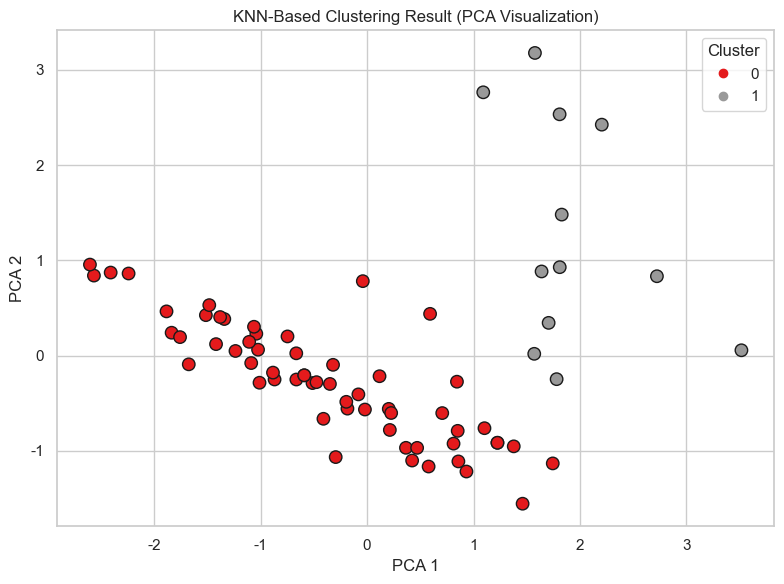


各群的樣本數量：
Cluster 0: 59 人
Cluster 1: 12 人

✅ 分群結果已儲存至：C:\Users\User\Downloads\KNN_Cluster_Result.xlsx


In [47]:
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 讀資料與標準化 (你原本的部分)
file_path = r"C:\Users\User\Downloads\酒精步態資料集受試者資訊 (回覆) (1).xlsx"
df = pd.read_excel(file_path)
df['性別'] = df['性別'].map({'男': 0, '女': 1})
features = df[['年齡(歲)', 'BMI', '身高(cm)']].dropna()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 1️⃣ 建立最近鄰圖（KNN 結構）
knn_graph = kneighbors_graph(X_scaled, n_neighbors=2, mode='connectivity', include_self=False)

# 2️⃣ 使用基於 KNN 結構的層次式分群（可分兩群）
model = AgglomerativeClustering(n_clusters=2, connectivity=knn_graph)
cluster_labels = model.fit_predict(X_scaled)

# 3️⃣ 加入到 dataframe 中
df_cleaned = df.loc[features.index].copy()
df_cleaned['KNN_Cluster'] = cluster_labels

# 4️⃣ PCA 降維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5️⃣ 視覺化結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='Set1', edgecolors='k', s=80)
plt.title('KNN-Based Clustering Result (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Cluster", loc="best")
plt.tight_layout()
plt.show()

# 3️⃣ 加入到 dataframe 中
df_cleaned = df.loc[features.index].copy()
df_cleaned['KNN_Cluster'] = cluster_labels

# ✅ 顯示各群的樣本數量
print("\n各群的樣本數量：")
cluster_counts = df_cleaned['KNN_Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} 人")


save_path = r"C:\Users\User\Downloads\KNN_Cluster_Result.xlsx"
df_cleaned.to_excel(save_path, index=False)
print(f"\n✅ 分群結果已儲存至：{save_path}")

C:\Users\User\AppData\Local\Temp\ipykernel_81360\1650516571.py:53: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_81360\1650516571.py:53: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_81360\1650516571.py:53: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_81360\1650516571.py:53: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_81360\1650516571.py:53: UserWarning: Glyph 32068 (\N{CJK UNIFIED IDEOGRAPH-7D44}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_81360\1650516571.py:53: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missi

('輪廓係數分析圖.png', '輪廓係數_特徵組合分析.xlsx')

d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\pythonProject\IC Lab\venv\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 32068 (\N{CJK UNIFIED IDEOGRAPH-7D44}) missing from font(s) Arial.
  fig.c

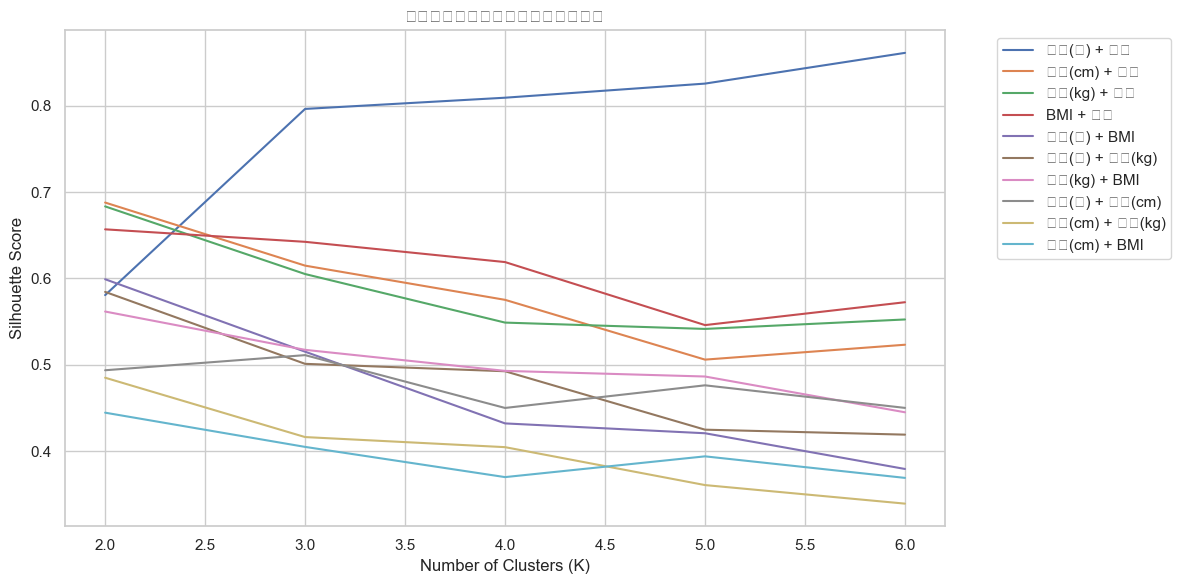

In [6]:
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import os

# 載入資料
file_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\info.xlsx"
df = pd.read_excel(file_path)

# 將性別轉換為數值
df['性別'] = df['性別'].map({'男': 0, '女': 1})

# 欲組合的特徵欄位
features = ['年齡(歲)', '身高(cm)', '體重(kg)', 'BMI', '性別']

# 所有兩兩組合
feature_combinations = list(itertools.combinations(features, 2))
results = []

# 計算輪廓係數
for combo in feature_combinations:
    subset = df[list(combo)].dropna()
    if len(subset) < 2:  # 避免資料過少無法聚類
        continue
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subset)
    for k in range(2, 7):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        results.append({'Feature1': combo[0], 'Feature2': combo[1], 'K': k, 'Silhouette Score': score})

# 轉為 DataFrame 並儲存
results_df = pd.DataFrame(results)
results_df.sort_values(by='Silhouette Score', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

# 儲存為 Excel
excel_path = "輪廓係數_特徵組合分析.xlsx"
results_df.to_excel(excel_path, index=False)

# 繪圖
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='K', y='Silhouette Score', hue=results_df['Feature1'] + ' + ' + results_df['Feature2'])
plt.title("不同特徵組合與分群數下的輪廓係數")
plt.ylabel("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 顯示資料表與儲存圖表
plt_path = "輪廓係數分析圖.png"
plt.savefig(plt_path)
plt_path, excel_path
